# Random Forest Regression

The objective of this notebook is to implement Random Forest Regression using Scikit-learn.

Random Forest Regression is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
project_root = Path.cwd().parent              # Data transformed from data transformation

train_path = project_root / "artifacts" / "data_transformation" / "train.npy"
test_path = project_root / "artifacts" / "data_transformation" / "test.npy"

train_arr = np.load(train_path)
test_arr = np.load(test_path)

In [4]:
X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]   # The transformed arrays contain both the input features and the target variable.

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

In [5]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)


In [6]:
model = RandomForestRegressor(
    n_estimators=100,       # It means the Random Forest will build 100 Decision Trees.
                            #Each tree makes a prediction, and the final prediction is the average of those 100 predictions.
    random_state=42
)

print(model)

RandomForestRegressor(random_state=42)


In [7]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predicted House Prices:")
print(y_pred[:5])
#The final prediction is obtained by averaging the predictions of all Decision Trees in the forest

Predicted House Prices:
[5357275.   7413280.   3748998.75 4501980.   3775835.  ]


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,4060000.0,5357275.00
1,6650000.0,7413280.00
2,3710000.0,3748998.75
3,6440000.0,4501980.00
4,2800000.0,3775835.00
5,4900000.0,3530730.00
6,5250000.0,5065130.00
7,4543000.0,5323430.00
8,2450000.0,2534560.00
9,3353000.0,2849367.50


In [11]:
mae = mean_absolute_error(y_test, y_pred)          #model evaluation

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1018219.70
Mean Squared Error (MSE): 1942928053330.26
Root Mean Squared Error (RMSE): 1393889.54
R² Score: 0.6156


In [12]:
feature_names = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus_furnished",
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

In [13]:
importance = model.feature_importances_       # feature imp

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
9,area,0.466367
11,bathrooms,0.150336
4,airconditioning,0.061637
13,parking,0.057153
12,stories,0.055782
10,bedrooms,0.047881
8,furnishingstatus_unfurnished,0.034066
2,basement,0.032138
5,prefarea,0.030573
3,hotwaterheating,0.016690


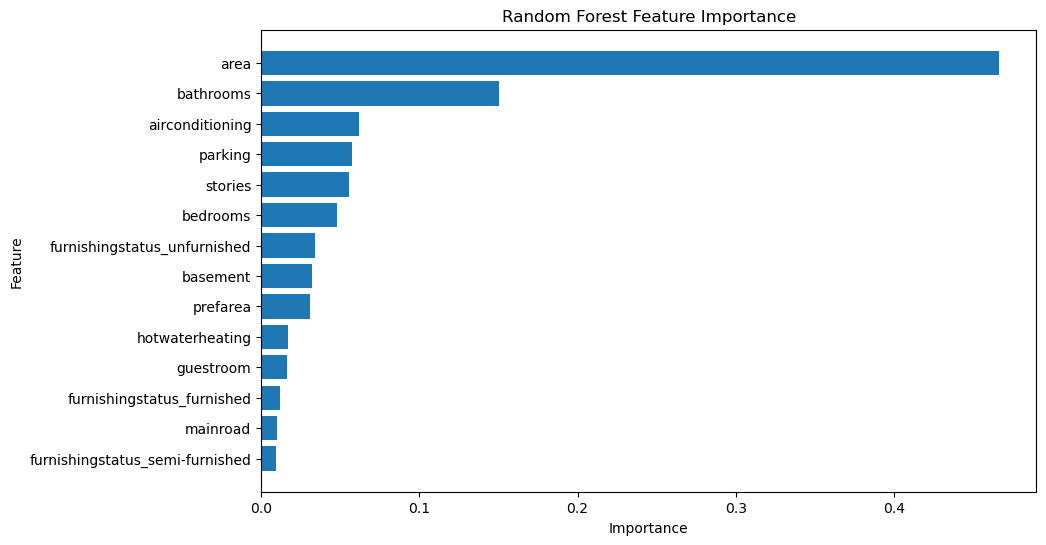

In [14]:
plt.figure(figsize=(10,6))           # plot feature imp

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

The graph shows how much each feature contributes to the Random Forest model's predictions. Features with higher importance have a greater influence on predicting house prices. In my model, the area feature has the highest importance, followed by bathrooms, indicating that these features contribute the most to the prediction